# 202235203 고수호
# **5week - wine.csv 데이터에 대한 DL_Classification**

# **# 라이브러리 임포트**

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# **# 데이터 세트 불러오기**

In [100]:
path = '/content/drive/MyDrive/Colab Notebooks/5week/wine.csv'
df = pd.read_csv(path)
df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


# **# Feature Selection을 위한 상관관계 확인**
종속변수 **'Wine'** 과의 상관관계
* **'Ash'** : 0.05
* **'Mg'** : 0.21
* **'Color.int'** : 0.27

<Axes: >

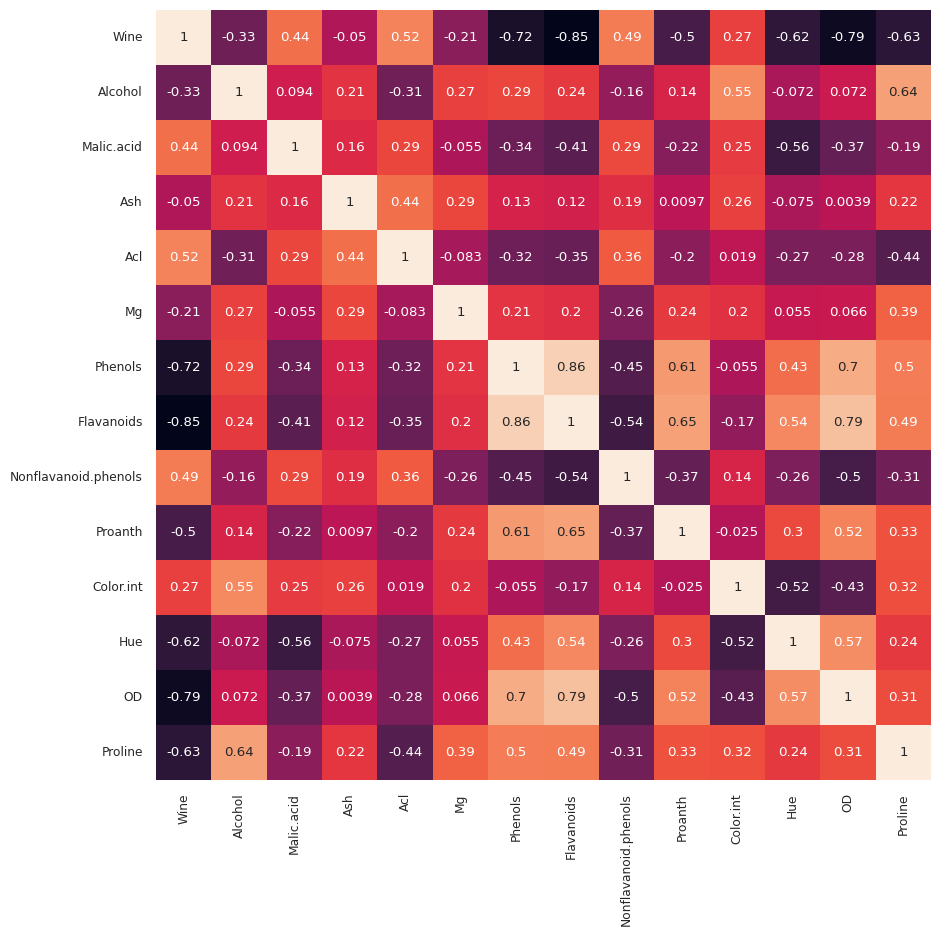

In [101]:
df_corr = df.corr()
plt.figure(figsize=(10,10))
sns.set(font_scale = 0.8)
sns.heatmap(df_corr, annot=True, cbar=False)

# **# 결측치 확인**

In [102]:
df.isnull().sum()

,0
Wine,0
Alcohol,0
Malic.acid,0
Ash,0
Acl,0
Mg,0
Phenols,0
Flavanoids,0
Nonflavanoid.phenols,0
Proanth,0


# **# 종속변수(y) 설정**

In [103]:
y=df['Wine']
y.value_counts()

,count
Wine,
2,71
1,59
3,48


# **# 원-핫 인코딩**

In [104]:
Y = pd.get_dummies(y).values

# **# 독립변수(X) 설정 및 Feature Selection**

In [105]:
X=df.drop(['Wine', 'Ash'], axis=1)
X.head()

,Alcohol,Malic.acid,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,14.23,1.71,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


# **# 딥러닝 입력을 위해 Numpy 배열로 변환**

In [106]:
X = X.values

# **# 데이터셋 분리 (Training & Test Set)**

In [107]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

# **# 딥러닝 모델 구성 및 학습**
**# 심층 신경망 구성**
```python
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(Y.shape[1], activation="softmax")
])
```
* **Sequential** : 레이어를 순차적으로 쌓는 모델의 컨테이너 역할.
* **Dense(64, activation="relu")** : 64개의 노드를 가진 첫 번째 은닉층. `input_shape`를 통해 입력 데이터의 특성 개수를 지정.
* **X.shape[1]** : 입력 데이터 X의 특성 개수를 의미.
* **layers.Dropout(0.3)** : 학습 시 무작위로 30%의 노드를 제외하여 **과적합(Overfitting) 방지**.
* **Dense(Y.shape[1], activation="softmax")** : 출력층. 다중 클래스 분류를 위해 클래스 수만큼 노드를 생성하고 확률값으로 변환하는 **Softmax** 사용.  

**# 학습 전략 설정**
```python
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
```
* **adam** : 효율적인 학습을 위한 최적화 알고리즘.
* **categorical_crossentropy** : 타겟 데이터가 **One-hot encoding**된 형태일 때 사용하는 **다중 분류** 손실 함수.
* **metrics=["accuracy"]** : 모델의 성능을 평가할 지표로 정확도(Accuracy)를 설정.  

**# 실제 학습 수행**
```python
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)
```
* **validation_split=0.2** : 학습 데이터 중 20%를 별도의 검증 세트로 분리하여 학습 중 성능 감시.
* **epochs=50** : 전체 데이터를 총 50회 반복 학습.
* **batch_size=16** : 16개의 데이터를 한 번의 가중치 업데이트 단위로 설정.
* **verbose=1** : 학습 진행 상황을 프로그레스 바 형태로 상세히 출력.

In [108]:
from tensorflow.keras import layers, models
from keras.optimizers import SGD,Adam

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(Y.shape[1], activation="softmax")   # 클래스 수 맞춤
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3451 - loss: 47.4192 - val_accuracy: 0.4483 - val_loss: 4.0684
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3451 - loss: 31.9311 - val_accuracy: 0.2759 - val_loss: 16.5751
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3097 - loss: 28.4077 - val_accuracy: 0.3793 - val_loss: 11.1325
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4071 - loss: 18.1260 - val_accuracy: 0.4483 - val_loss: 4.4434
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3451 - loss: 18.9062 - val_accuracy: 0.3103 - val_loss: 2.8644
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3628 - loss: 20.1501 - val_accuracy: 0.2759 - val_loss: 3.7498
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3894 - loss: 21.6188 - val_accuracy: 0.2759 - val_loss: 3.9773
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3894 - loss: 16.2162 - val_accuracy: 0.4483 - val_loss: 2.8555
Epoch 9

# **# 모델 예측 및 클래스 변환**

```python
y_pred = model.predict(X_test)
```
* **model.predict(X_test)** : 학습된 모델을 사용하여 테스트 데이터(`X_test`)에 대한 예측값을 계산.
* **출력값** : 출력층의 활성화 함수가 `softmax`이므로, 각 샘플이 각 클래스에 속할 확률(0~1 사이 값)을 담은 행렬이 반환됨.

```python
y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)
```
* **np.argmax(..., axis=1)** : 각 행(샘플)에서 가장 큰 값(확률)을 가진 인덱스를 반환하여 클래스 번호로 변환.
* **y_test_class** : One-hot encoding된 실제 정답(`y_test`)을 비교를 위해 원래의 레이블 번호로 복원.
* **y_pred_class** : 모델이 예측한 확률 배열에서 가장 높은 확률을 가진 클래스를 최종 예측 클래스로 결정.

In [109]:
y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


# **# 학습 및 검증 손실 시각화**

```python
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
```
* **loss** : 매 에포크(epoch)마다 학습 데이터(Train Data)를 통해 계산된 모델의 손실값.
* **val_loss** : 매 에포크마다 검증 데이터(Validation Data)를 통해 계산된 모델의 손실값. 모델의 **과적합(Overfitting)** 여부를 판단하는 핵심 지표.
* **epochs** : 그래프의 x축으로 사용하기 위해 1부터 손실 데이터의 개수만큼의 범위를 생성.

```python
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
```
* **'y' / 'r'** : 학습 손실은 **노란색(Yellow)**, 검증 손실은 **빨간색(Red)** 선으로 표시.
* **label** : 범례(Legend)에 표시될 각 선의 이름 설정.

```python
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
```
* **plt.title** : 그래프의 제목 설정.
* **plt.xlabel / ylabel** : x축(에포크 수)과 y축(손실값)의 이름 설정.

```python
plt.legend()
plt.show()
```
* **plt.legend()** : 설정한 레이블(`Training loss`, `Validation loss`)을 그래프 내 상자에 표시.
* **plt.show()** : 구성된 그래프를 화면에 출력. 이 그래프를 통해 모델이 적절히 학습되었는지 또는 **과적합(Overfitting)**이 발생했는지 시각적으로 판단 가능.

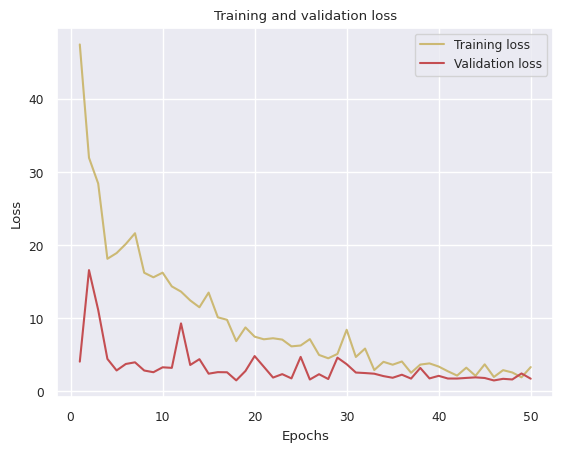

In [110]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# **# 학습 및 검증 정확도 시각화**

```python
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
```
* **acc** : 학습 데이터에 대한 모델의 분류 정확도.
* **val_acc** : 검증 데이터에 대한 모델의 분류 정확도. 실제 학습에 사용되지 않은 데이터에 대해 모델이 얼마나 잘 일반화되었는지 확인.
* **역할** : 모델이 훈련 데이터와 처음 보는 데이터(검증 데이터)에 대해 얼마나 정답을 잘 맞히는지 추이를 확인.

```python
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
```
* **'y' / 'r'** : 학습 정확도는 **노란색(Yellow)**, 검증 정확도는 **빨간색(Red)** 선으로 시각화.
* **비교 포인트** : 두 선이 함께 완만하게 상승하면 학습이 잘 되는 것이나, 학습 정확도만 높고 검증 정확도가 낮다면 **과적합(Overfitting)**을 의심해야 함.

```python
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
```
* **plt.title** : 그래프의 제목을 "Training and validation accuracy"로 설정.
* **plt.xlabel / ylabel** : x축은 학습 횟수인 **Epochs**, y축은 정확도 수치인 **Accuracy**로 설정.

```python
plt.legend()
plt.show()
```
* **plt.legend()** : 그래프 우측 상단 등에 각 선의 이름(범례)을 표시.
* **plt.show()** : 최종적으로 생성된 정확도 추이 그래프를 출력.

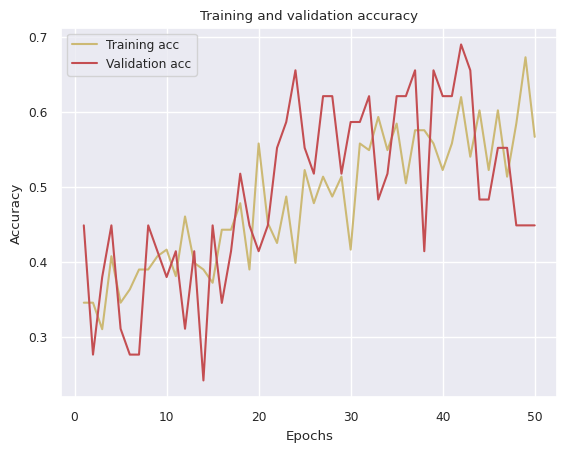

In [111]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# **# 예측 결과 평가 및 성능 분석**

```python
from sklearn.metrics import classification_report, confusion_matrix
```
*   **classification_report**: 정밀도(Precision), 재현율(Recall), F1-score 등 분류 모델의 주요 평가 지표를 한 번에 계산하는 도구.
*   **confusion_matrix**: 오차 행렬. 실제 클래스와 모델이 예측한 클래스의 관계를 표 형태로 나타냄.

```python
print(classification_report(y_test_class, y_pred_class))
```
*   **역할**: 테스트 데이터의 실제 값(`y_test_class`)과 모델의 예측 값(`y_pred_class`)을 비교하여 종합적인 성능 보고서 출력.
*   **주요 지표**:
    *   **Precision (정밀도)**: 모델이 특정 클래스로 예측한 것 중 실제 정답인 비율.
    *   **Recall (재현율)**: 실제 정답인 데이터 중 모델이 맞춘 비율.
    *   **F1-score**: 정밀도와 재현율의 조화 평균값.

```python
print(confusion_matrix(y_test_class, y_pred_class))
```
*   **역할**: 예측 결과를 **행(실제 값)과 열(예측 값)**로 구성된 행렬로 출력하여 어떤 클래스를 혼동하고 있는지 구체적으로 파악.

In [112]:
#Accuracy of the predicted values
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.80      0.25      0.38        16
           2       0.24      0.67      0.35         6

    accuracy                           0.58        36
   macro avg       0.65      0.62      0.55        36
weighted avg       0.76      0.58      0.59        36

[[13  0  1]
 [ 0  4 12]
 [ 1  1  4]]
